## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
data = pd.read_csv("C:/Users/sahil/Downloads/nlptask (1).csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {data.shape}")
data.head()

Dataset loaded successfully!
Dataset shape: (119801, 16)


,Unnamed: 0,id,created_at,source,original_text,lang,favorite_count,retweet_count,hashtags,user_mentions,place,compound,neg,neu,pos,sentiment
0,0,1386694264550270000,2021-04-26,"<a href=""http://twitter.com/download/android"" ...",RT @VP: The U.S. is working closely with the I...,en,0.0,0.0,NaN,VP,Alabama,0.0772,0.170,0.638,0.191,pos
1,1,1386694260213170000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...",RT @JackPosobiec: Flip-Flop Fauci admits outdo...,en,0.0,0.0,NaN,JackPosobiec,NaN,-0.4019,0.398,0.442,0.159,neg
2,2,1386694256413320000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...","RT @timmy315: Hi Twitter, I’m Tim Manning, the...",en,0.0,252.0,NaN,timmy315,NaN,0.0000,0.000,1.000,0.000,neu
3,3,1386694252017630000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",RT @itsaadee: Praying for #India as the countr...,en,0.0,2.0,"India, Covid",itsaadee,NaN,-0.4215,0.306,0.522,0.172,neg
4,4,1386694248284700000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",Rapid Investment in Nursing to Strengthen the ...,en,0.0,7937.0,NaN,NaN,UK,0.3182,0.000,0.723,0.277,pos


## 3. Explore Dataset

In [3]:
print("Dataset Information:")
print(data.info())
print("\nColumn Names:")
print(data.columns.tolist())
print("\nFirst few rows:")
print(data.head())
print("\nData types:")
print(data.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119801 entries, 0 to 119800
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      119801 non-null  int64  
 1   id              119801 non-null  int64  
 2   created_at      119801 non-null  object 
 3   source          119801 non-null  object 
 4   original_text   119801 non-null  object 
 5   lang            119799 non-null  object 
 6   favorite_count  119799 non-null  float64
 7   retweet_count   119799 non-null  float64
 8   hashtags        31516 non-null   object 
 9   user_mentions   82387 non-null   object 
 10  place           83425 non-null   object 
 11  compound        119800 non-null  float64
 12  neg             119800 non-null  float64
 13  neu             119800 non-null  float64
 14  pos             119800 non-null  float64
 15  sentiment       119800 non-null  object 
dtypes: float64(6), int64(2), object(8)


In [4]:
print("Missing Values:")
print(data.isnull().sum())
print("\nDataset Statistics (numeric columns only):")
print(data.describe())

Missing Values:
Unnamed: 0            0
id                    0
created_at            0
source                0
original_text         0
lang                  2
favorite_count        2
retweet_count         2
hashtags          88285
user_mentions     37414
place             36376
compound              1
neg                   1
neu                   1
pos                   1
sentiment             1
dtype: int64

Dataset Statistics (numeric columns only):
          Unnamed: 0            id  favorite_count  retweet_count  \
count  119801.000000  1.198010e+05   119799.000000  119799.000000   
mean    59900.000000  1.396241e+18        0.265570     495.900200   
std     34583.714137  4.983574e+15        9.756049    3098.799886   
min         0.000000  1.386693e+18        0.000000       0.000000   
25%     29950.000000  1.391132e+18        0.000000       1.000000   
50%     59900.000000  1.397257e+18        0.000000      12.000000   
75%     89850.000000  1.400440e+18        0.000000     150.0

## 4. Data Preprocessing

In [5]:
# Check for numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Check for text columns
text_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"Text columns: {text_cols}")

Numeric columns: ['Unnamed: 0', 'id', 'favorite_count', 'retweet_count', 'compound', 'neg', 'neu', 'pos']
Text columns: ['created_at', 'source', 'original_text', 'lang', 'hashtags', 'user_mentions', 'place', 'sentiment']


In [6]:
# If dataset has sentiment/label column, convert to numeric
# Common sentiment column names
sentiment_col = None
for col in ['sentiment', 'Sentiment', 'label', 'Label', 'target', 'Target']:
    if col in data.columns:
        sentiment_col = col
        break

if sentiment_col:
    print(f"Found sentiment column: {sentiment_col}")
    print(f"Unique values: {data[sentiment_col].unique()}")
    
    # Convert categorical sentiment to numeric
    if data[sentiment_col].dtype == 'object':
        sentiment_map = {val: idx for idx, val in enumerate(data[sentiment_col].unique())}
        data[sentiment_col + '_numeric'] = data[sentiment_col].map(sentiment_map)
        print(f"Sentiment mapping: {sentiment_map}")
else:
    print("No sentiment column found")

Found sentiment column: sentiment
Unique values: ['pos' 'neg' 'neu' nan]
Sentiment mapping: {'pos': 0, 'neg': 1, 'neu': 2, nan: 3}


## 5. Feature Engineering - Convert Text to Numeric Features

In [7]:
# Find text column for analysis
text_col = None
for col in ['text', 'Text', 'tweet', 'Tweet', 'message', 'Message', 'content', 'Content']:
    if col in data.columns:
        text_col = col
        break

if text_col:
    print(f"Found text column: {text_col}")
    
    # Create simple text features
    data['text_length'] = data[text_col].astype(str).apply(len)
    data['word_count'] = data[text_col].astype(str).apply(lambda x: len(x.split()))
    data['avg_word_length'] = data['text_length'] / (data['word_count'] + 1)
    
    # Count specific keywords
    data['positive_words'] = data[text_col].astype(str).str.lower().str.count('good|great|excellent|happy|positive')
    data['negative_words'] = data[text_col].astype(str).str.lower().str.count('bad|terrible|awful|sad|negative')
    data['covid_words'] = data[text_col].astype(str).str.lower().str.count('covid|coronavirus|pandemic|virus')
    
    print("Text features created successfully!")
else:
    print("No text column found, using available numeric features")

No text column found, using available numeric features


## 6. Prepare Final Dataset

In [8]:
# Select only numeric columns for modeling
numeric_data = data.select_dtypes(include=[np.number])

# Remove any rows with missing values
numeric_data = numeric_data.dropna()

print(f"Cleaned numeric data shape: {numeric_data.shape}")
print(f"Available numeric columns: {numeric_data.columns.tolist()}")

Cleaned numeric data shape: (119799, 9)
Available numeric columns: ['Unnamed: 0', 'id', 'favorite_count', 'retweet_count', 'compound', 'neg', 'neu', 'pos', 'sentiment_numeric']


## 7. Data Visualization

AttributeError: module 'seaborn' has no attribute 'show'

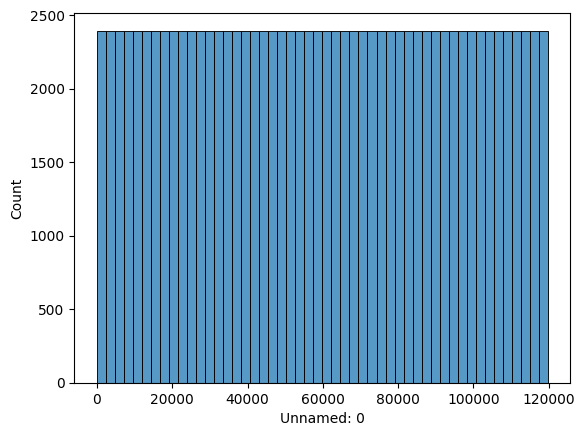

In [9]:
# Visualize distribution of first few numeric columns
if len(numeric_data.columns) > 0:
    for col in numeric_data.columns[:3]:  # First 3 columns
        sns.histplot(data=numeric_data[col])
        sns.show()

AttributeError: module 'seaborn' has no attribute 'show'

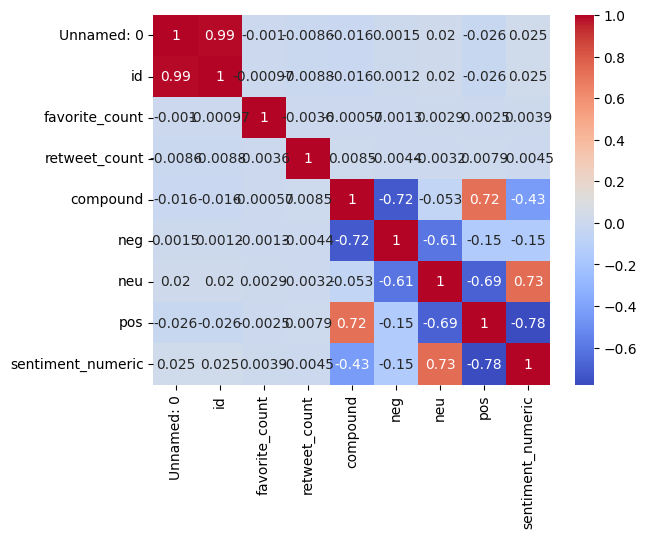

In [10]:
# Correlation heatmap (only if we have multiple numeric columns)
if len(numeric_data.columns) > 1:
    sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
    sns.show()

## 8. Prepare Features and Target

In [ ]:
# Prepare features (X) and target (y)
# Use last column as target, rest as features
X = numeric_data.iloc[:, :-1].values
y = numeric_data.iloc[:, -1].values

# Ensure y is 1D array
y = np.ravel(y)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

## 9. Split Data

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

## 10. Feature Scaling

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

## 11. Train Linear Regression Model

In [ ]:
# Initialize Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed!")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

## 12. Make Predictions

In [ ]:
# Predict on training data
y_train_pred = model.predict(X_train_scaled)

# Predict on testing data
y_test_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print(f"\nFirst 10 actual values: {y_test[:10]}")
print(f"First 10 predictions: {y_test_pred[:10]}")

## 13. Model Evaluation

In [ ]:
# Calculate R-squared score
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print("Model Performance:")
print("=" * 50)
print(f"Training R² Score: {train_score:.4f}")
print(f"Testing R² Score: {test_score:.4f}")

In [ ]:
# Calculate Mean Squared Error
train_mse = np.mean((y_train - y_train_pred) ** 2)
test_mse = np.mean((y_test - y_test_pred) ** 2)

print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")

In [ ]:
# Calculate Mean Absolute Error
train_mae = np.mean(np.abs(y_train - y_train_pred))
test_mae = np.mean(np.abs(y_test - y_test_pred))

print(f"Training MAE: {train_mae:.4f}")
print(f"Testing MAE: {test_mae:.4f}")

## 14. Visualize Results

In [ ]:
# Plot actual vs predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
sns.scatterplot(data=results_df, x='Actual', y='Predicted')
sns.show()

In [ ]:
# Plot residuals
residuals = y_test - y_test_pred
sns.histplot(residuals, kde=True)
sns.show()

In [ ]:
# Distribution of actual vs predicted
comparison_df = pd.DataFrame({
    'Type': ['Actual']*len(y_test) + ['Predicted']*len(y_test_pred),
    'Value': np.concatenate([y_test, y_test_pred])
})
sns.boxplot(data=comparison_df, x='Type', y='Value')
sns.show()

In [ ]:
# Residual plot
sns.scatterplot(x=y_test_pred, y=residuals)
sns.show()

## 15. Feature Importance Analysis

In [ ]:
# Get feature importance (coefficients)
feature_names = numeric_data.columns[:-1].tolist()
coefficients = model.coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("Feature Importance (Based on Coefficients):")
print(importance_df)

In [ ]:
# Visualize feature importance
sns.barplot(data=importance_df, x='Abs_Coefficient', y='Feature')
sns.show()

## 16. Summary

In [ ]:
print("COVID-19 Sentiment Analysis - Summary")
print("=" * 60)
print(f"Total samples: {len(data)}")
print(f"Samples after cleaning: {len(numeric_data)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nModel Performance:")
print(f"Training R² Score: {train_score:.4f}")
print(f"Testing R² Score: {test_score:.4f}")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training MAE: {train_mae:.4f}")
print(f"Testing MAE: {test_mae:.4f}")
print("=" * 60)
print("Analysis Complete!")